In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


ROOT = "../simulacoes/predlen_loss_todos_ativos"
ARQ = f"{ROOT}/comparativo_metricas_long.csv"

THRESHOLD_PRECISION = 0.595
THRESHOLD_IC = 0.05

df_long = pd.read_csv(ARQ)

KEYS = ["tipo_serie", "modelo", "lookback", "pred_len", "janela_previsao"]

df_wide = (
    df_long
    .pivot_table(
        index=KEYS,
        columns="estatistica",
        values="valor",
        aggfunc="first",
    )
    .reset_index()
)

df_wide = df_wide.rename(columns={"tipo_serie": "tipo_dado"})

#df_export = df_wide[df_wide["mean_precision_positive"] >= THRESHOLD_PRECISION].copy()
df_export = df_wide[df_wide["mean_spearman_ic"] >= THRESHOLD_IC].copy()

df_export.shape

(5, 15)

In [6]:
pct_prices = (df_export["tipo_dado"] == "prices").mean() * 100
print(f"A. Percentual de 'prices' em tipo_dado: {pct_prices:.2f}%")
print("-" * 50)

print("B. Distribuição percentual de lookback:")
print((df_export["lookback"].value_counts(normalize=True) * 100).map("{:.2f}%".format))
print("-" * 50)

print("C. Distribuição percentual de pred_len:")
print((df_export["pred_len"].value_counts(normalize=True) * 100).map("{:.2f}%".format))
print("-" * 50)

print("D. Distribuição percentual de janela_previsao:")
print((df_export["janela_previsao"].value_counts(normalize=True) * 100).map("{:.2f}%".format))
print("-" * 50)

print("E. Distribuição percentual de modelo:")
print((df_export["modelo"].value_counts(normalize=True) * 100).map("{:.2f}%".format))

A. Percentual de 'prices' em tipo_dado: 0.00%
--------------------------------------------------
B. Distribuição percentual de lookback:
lookback
32     60.00%
104    40.00%
Name: proportion, dtype: str
--------------------------------------------------
C. Distribuição percentual de pred_len:
pred_len
24    80.00%
15    20.00%
Name: proportion, dtype: str
--------------------------------------------------
D. Distribuição percentual de janela_previsao:
janela_previsao
10    40.00%
20    40.00%
24    20.00%
Name: proportion, dtype: str
--------------------------------------------------
E. Distribuição percentual de modelo:
modelo
AttentionSoloChannelIndependentSharedSpecific    60.00%
AttentionSoloChannelIndependent                  20.00%
TransformerShrINSpec                             20.00%
Name: proportion, dtype: str


In [7]:
tab_pred_k = (
    df_export
    .groupby(["pred_len", "janela_previsao"])
    .size()
    .rename("n")
    .reset_index()
)

tab_pred_k["pct_global"] = 100 * tab_pred_k["n"] / tab_pred_k["n"].sum()

tab_pred_k["pct_dentro_pred_len"] = (
    tab_pred_k
    .groupby("pred_len")["n"]
    .transform(lambda x: 100 * x / x.sum())
)

tab_pred_k


,pred_len,janela_previsao,n,pct_global,pct_dentro_pred_len
0,15,10,1,20.0,100.0
1,24,10,1,20.0,25.0
2,24,20,2,40.0,50.0
3,24,24,1,20.0,25.0


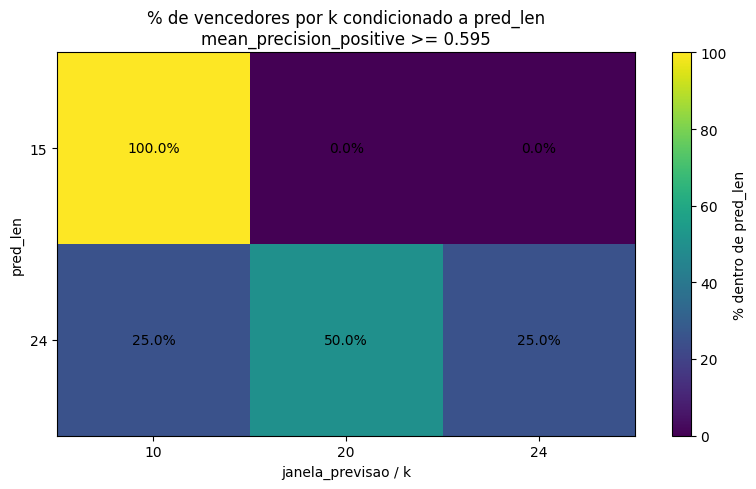

In [8]:

heat = tab_pred_k.pivot(
    index="pred_len",
    columns="janela_previsao",
    values="pct_dentro_pred_len",
).fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(heat.values, aspect="auto")

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)

ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)

ax.set_xlabel("janela_previsao / k")
ax.set_ylabel("pred_len")
ax.set_title(f"% de vencedores por k condicionado a pred_len\nmean_precision_positive >= {THRESHOLD_PRECISION}")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.1f}%", ha="center", va="center")

plt.colorbar(im, ax=ax, label="% dentro de pred_len")
plt.tight_layout()
plt.show()

In [9]:
resumo_pred_k = (
    df_wide
    .groupby(["pred_len", "janela_previsao"])
    .agg(
        n=("mean_precision_positive", "size"),
        precision_media=("mean_precision_positive", "mean"),
        precision_mediana=("mean_precision_positive", "median"),
        precision_max=("mean_precision_positive", "max"),
        sharpe_medio=("sharpe", "mean"),
        retorno_medio=("annual_return", "mean"),
    )
    .reset_index()
    .sort_values(["pred_len", "janela_previsao"])
)

resumo_pred_k

,pred_len,janela_previsao,n,precision_media,precision_mediana,precision_max,sharpe_medio,retorno_medio
0,1,1,30,0.477420,0.478129,0.501660,0.149668,0.087936
1,5,1,30,0.479411,0.477679,0.498132,0.223368,0.106676
2,5,5,30,0.504163,0.500492,0.540806,0.414774,0.138622
3,10,1,30,0.478358,0.474603,0.496627,0.047414,0.063538
4,10,5,30,0.501150,0.501984,0.529762,0.364138,0.126442
5,10,10,30,0.511102,0.509921,0.547619,0.390210,0.130278
6,15,1,30,0.480317,0.477578,0.507708,0.337074,0.128413
7,15,5,30,0.505274,0.501502,0.536537,0.367085,0.125668
8,15,10,30,0.512842,0.502976,0.565476,0.439877,0.141890
9,15,15,30,0.529989,0.527027,0.591592,0.524496,0.165413


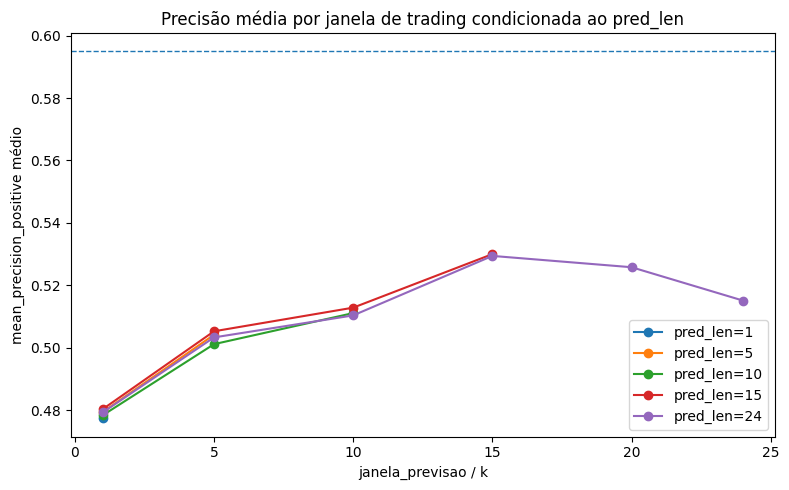

In [10]:
plt.figure(figsize=(8, 5))

for pred_len, base in resumo_pred_k.groupby("pred_len"):
    plt.plot(
        base["janela_previsao"],
        base["precision_media"],
        marker="o",
        label=f"pred_len={pred_len}",
    )

plt.axhline(THRESHOLD_PRECISION, linestyle="--", linewidth=1)

plt.xlabel("janela_previsao / k")
plt.ylabel("mean_precision_positive médio")
plt.title("Precisão média por janela de trading condicionada ao pred_len")
plt.legend()
plt.tight_layout()
plt.show()

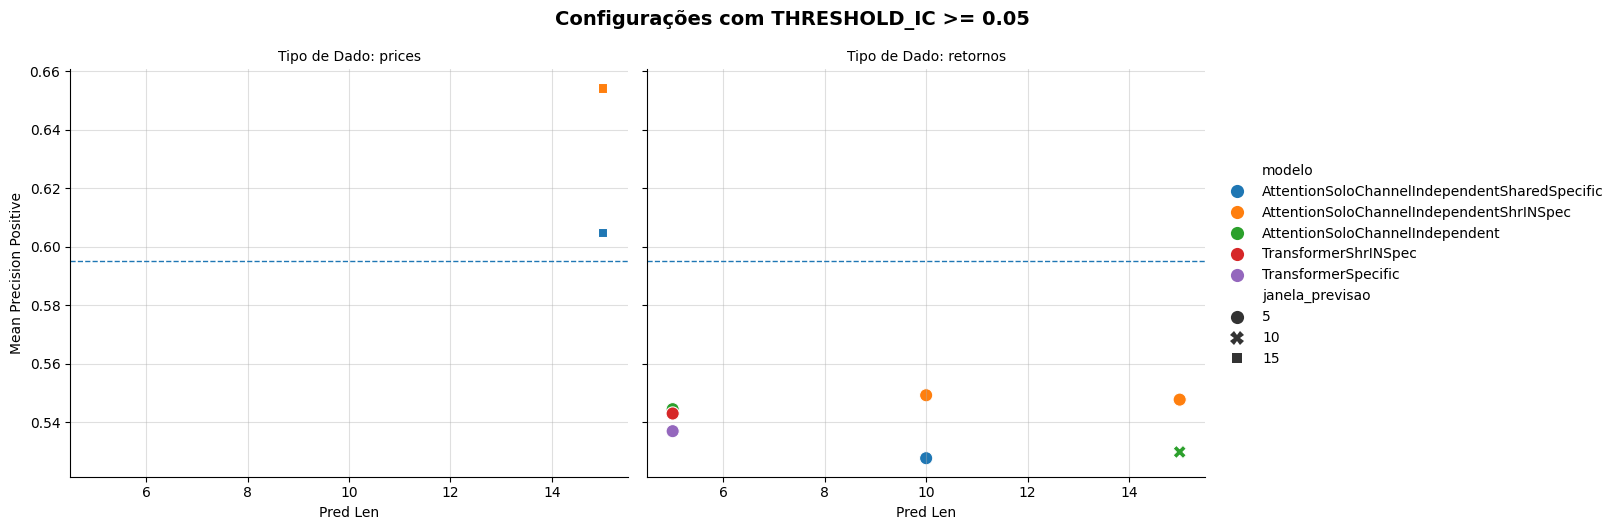

In [20]:
THRESHOLD_IC = 0.05
MIN_N_ASSETS = 1.0

df_export = df_wide[
    (df_wide["mean_spearman_ic"] >= THRESHOLD_IC) &
    (df_wide["mean_n_assets"] >= MIN_N_ASSETS)
].copy()


df_plot = df_export.copy()

df_plot["lookback_label"] = "lookback_" + df_plot["lookback"].astype(int).astype(str)
df_plot["k_label"] = "k_" + df_plot["janela_previsao"].astype(int).astype(str)

g = sns.relplot(
    data=df_plot,
    x="pred_len",
    y="mean_precision_positive",
    hue="modelo",
    style="janela_previsao",
    col="tipo_dado",
    kind="scatter",
    height=5,
    aspect=1.25,
    s=90,
)

g.set_axis_labels("Pred Len", "Mean Precision Positive")
g.set_titles("Tipo de Dado: {col_name}")

for ax in g.axes.flat:
    ax.axhline(THRESHOLD_PRECISION, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.4)

g.fig.suptitle(
    f"Configurações com THRESHOLD_IC >= {THRESHOLD_IC}",
    y=1.05,
    fontsize=14,
    fontweight="bold",
)

plt.show()

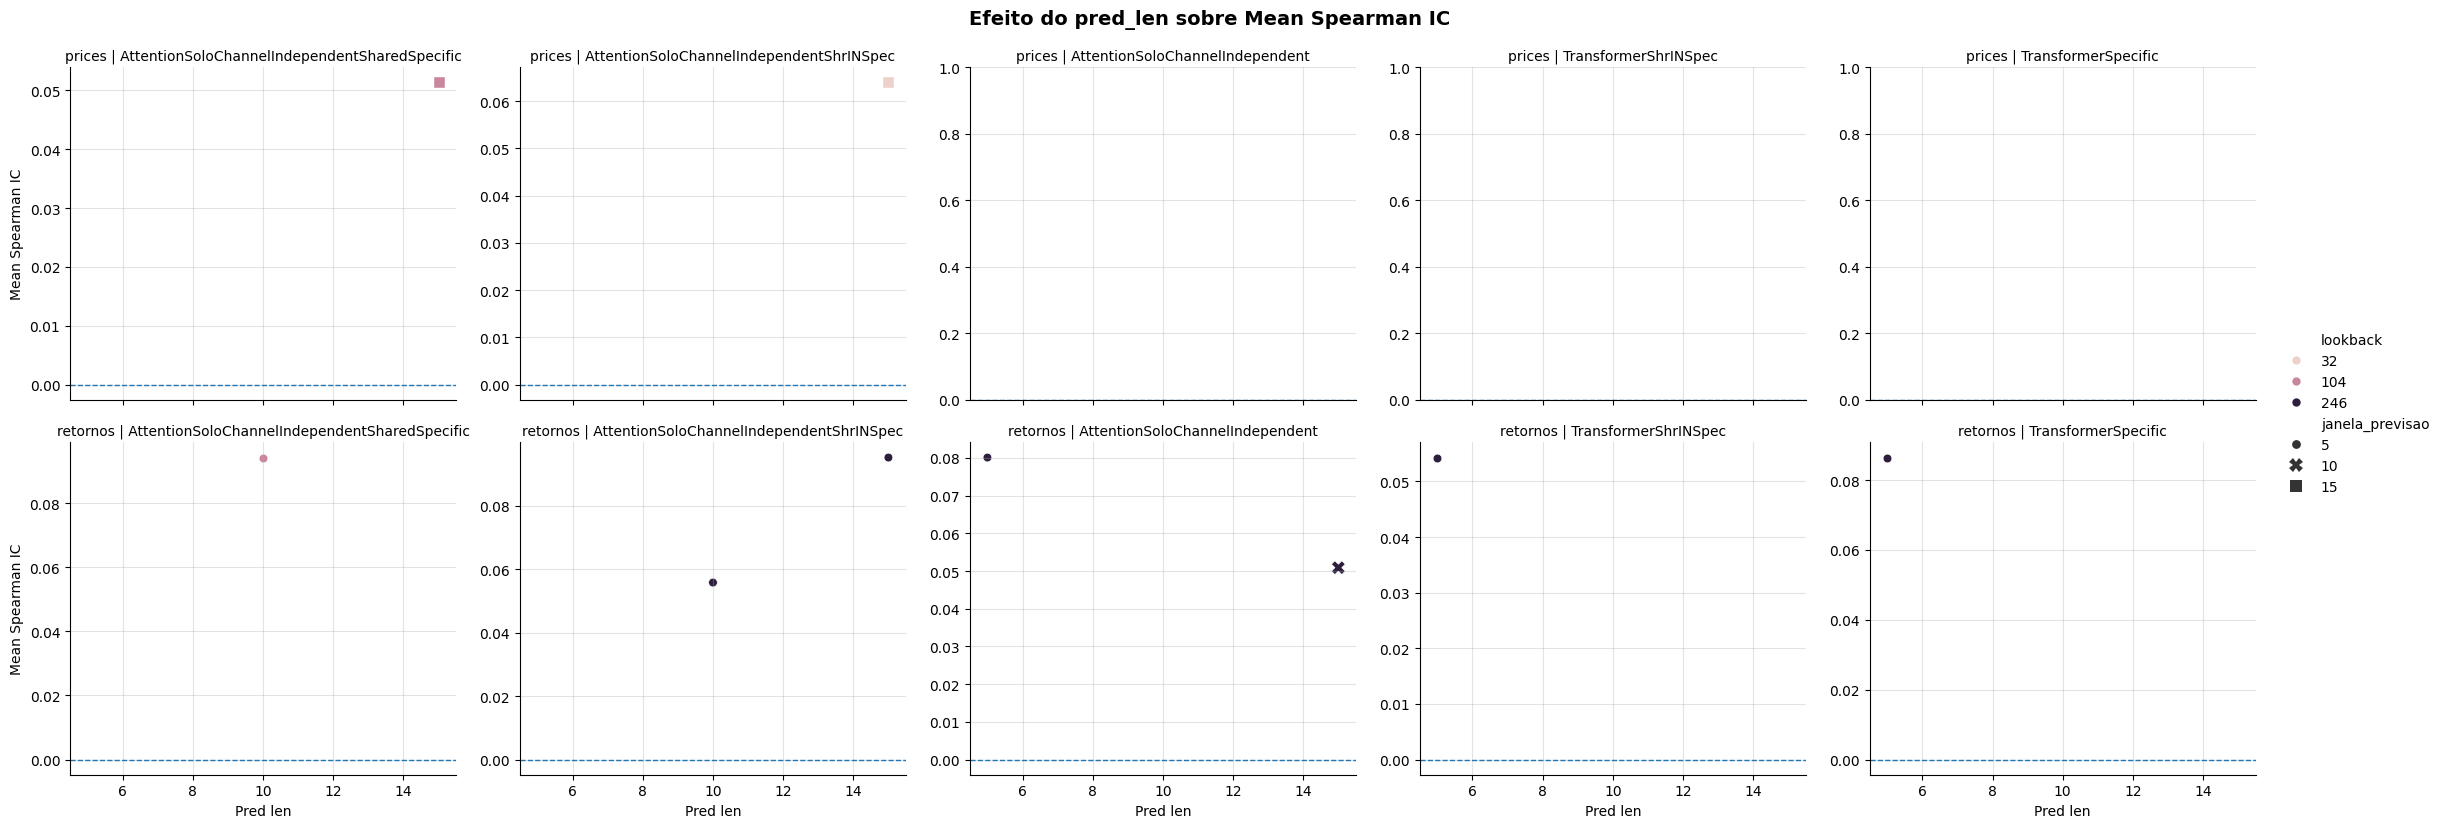

In [ ]:

KEYS = ["tipo_serie", "modelo", "lookback", "pred_len", "janela_previsao"]

df_wide = (
    df_long
    .pivot_table(
        index=KEYS,
        columns="estatistica",
        values="valor",
        aggfunc="first",
    )
    .reset_index()
    .rename(columns={"tipo_serie": "tipo_dado"})
)

df_wide["lookback"] = df_wide["lookback"].astype(int)
df_wide["pred_len"] = df_wide["pred_len"].astype(int)
df_wide["janela_previsao"] = df_wide["janela_previsao"].astype(int)

THRESHOLD_IC = 0.05
MIN_N_ASSETS = 1.0

df_plot = df_wide[
    (df_wide["mean_spearman_ic"] >= THRESHOLD_IC) &
    (df_wide["mean_n_assets"] >= MIN_N_ASSETS)
].copy()




g = sns.relplot(
    data=df_plot,
    x="pred_len",
    y="mean_spearman_ic",
    hue="lookback",
    style="janela_previsao",
    size="janela_previsao",
    col="modelo",
    row="tipo_dado",
    kind="scatter",
    height=4,
    aspect=1.15,
    sizes=(40, 160),
    facet_kws={"sharey": False},
)

g.set_axis_labels("Pred len", "Mean Spearman IC")
g.set_titles("{row_name} | {col_name}")

for ax in g.axes.flat:
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.35)

g.fig.suptitle(
    "Efeito do pred_len sobre Mean Spearman IC",
    y=1.03,
    fontsize=14,
    fontweight="bold",
)

plt.show()

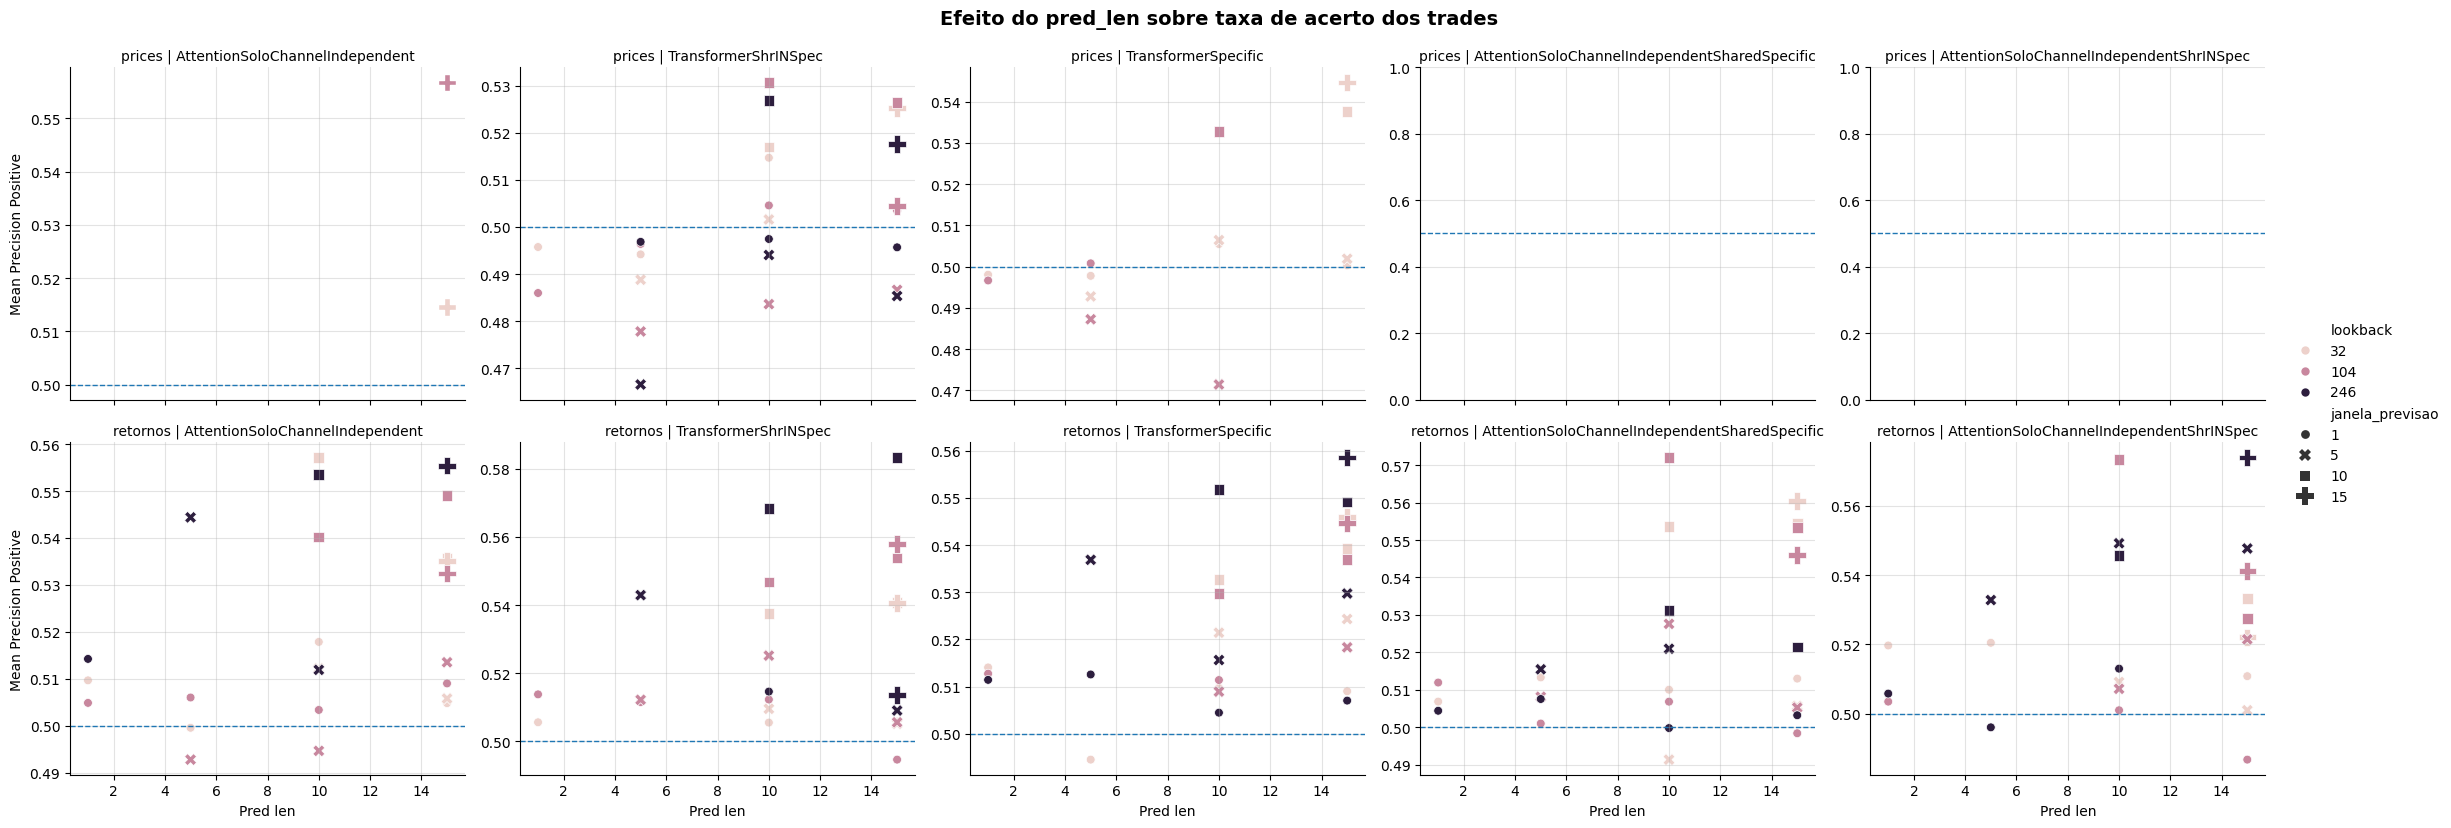

In [18]:
MIN_N_ASSETS = 3.0

df_plot = df_wide[df_wide["mean_n_assets"] >= MIN_N_ASSETS].copy()



g = sns.relplot(
    data=df_plot,
    x="pred_len",
    y="mean_precision_positive",
    hue="lookback",
    style="janela_previsao",
    size="janela_previsao",
    col="modelo",
    row="tipo_dado",
    kind="scatter",
    height=4,
    aspect=1.15,
    sizes=(40, 160),
    facet_kws={"sharey": False},
)

g.set_axis_labels("Pred len", "Mean Precision Positive")
g.set_titles("{row_name} | {col_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.35)

g.fig.suptitle(
    "Efeito do pred_len sobre taxa de acerto dos trades",
    y=1.03,
    fontsize=14,
    fontweight="bold",
)

plt.show()
g.set_axis_labels("Pred len", "Mean Precision Positive")
g.set_titles("{row_name} | {col_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.35)

g.fig.suptitle(
    "Efeito do pred_len sobre taxa de acerto dos trades",
    y=1.03,
    fontsize=14,
    fontweight="bold",
)

plt.show()

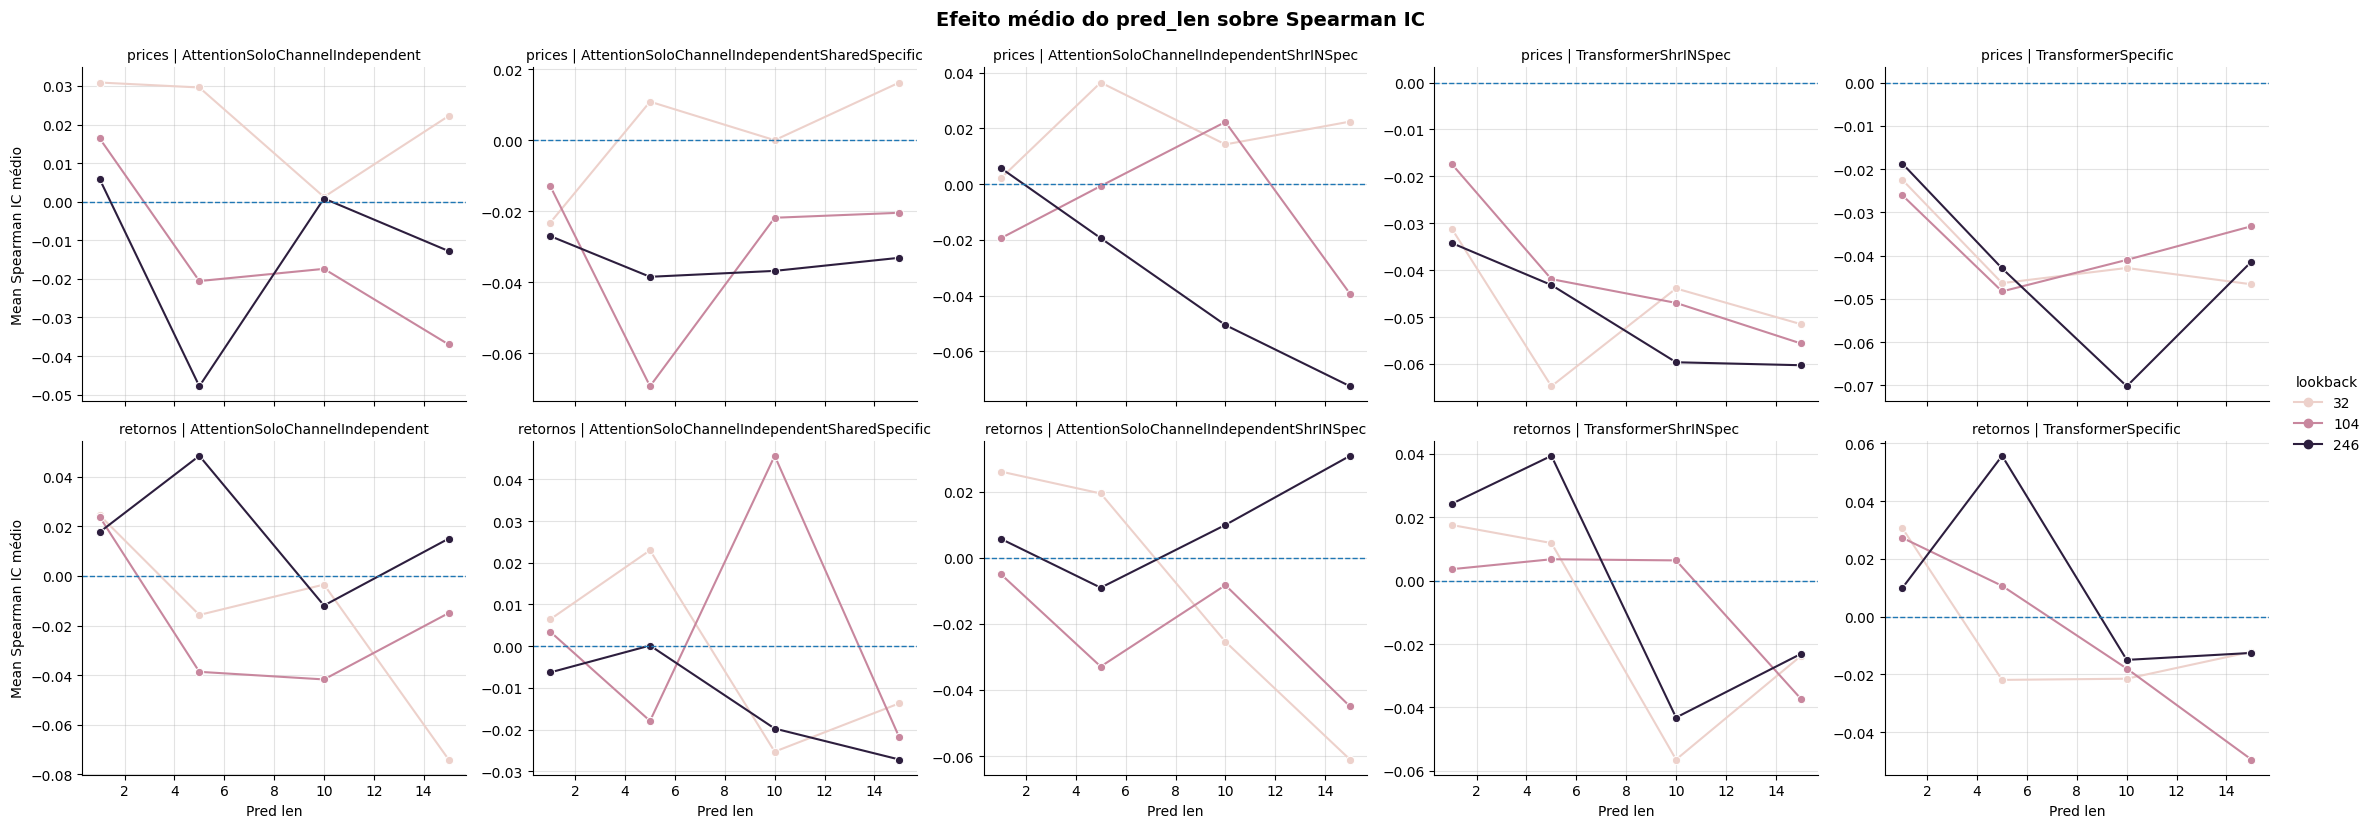

In [14]:
resumo_predlen = (
    df_wide
    .groupby(["tipo_dado", "modelo", "lookback", "pred_len"])
    .agg(
        spearman_medio=("mean_spearman_ic", "mean"),
        spearman_max=("mean_spearman_ic", "max"),
        precision_media=("mean_precision_positive", "mean"),
        precision_max=("mean_precision_positive", "max"),
        n_configs=("mean_spearman_ic", "size"),
    )
    .reset_index()
)
g = sns.relplot(
    data=resumo_predlen,
    x="pred_len",
    y="spearman_medio",
    hue="lookback",
    col="modelo",
    row="tipo_dado",
    kind="line",
    marker="o",
    height=4,
    aspect=1.15,
    facet_kws={"sharey": False},
)

g.set_axis_labels("Pred len", "Mean Spearman IC médio")
g.set_titles("{row_name} | {col_name}")

for ax in g.axes.flat:
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.35)

g.fig.suptitle(
    "Efeito médio do pred_len sobre Spearman IC",
    y=1.03,
    fontsize=14,
    fontweight="bold",
)

plt.show()